![image](via_en_logo.png)

## <center>Practical Work 6</center>
### <center>Group 4</center>
 ![image](movie_picture.jpg)
## <center>Data on Movies!</center>

### Authors:
| Name, surname    | Role | E-mail |
| -------- | ------- | ------- |
| Ēriks Ralfs Matulis  | Coordinator    | eriksralfs.matulis@va.lv |
| Marks Ābele  | Member    | marks.abele@va.lv |

## 1. Goal

The goal of this practical work is to create at least 3 plots using plotting libraries such as Seaborn and Matplotlib, and to provide analysis on the most popular genre over all movies, the best and worst grossing keywords associated with the movies, and a heatmap with a linear correlation graph for numerical values. Since the plots rely on the data from the previous practical work, it has been left as is in this practical work. 
<br>
To quickly jump to the PW6 plots, use the navigation menu or this [anchor link](#7.-Practical-Work-6-plots).

# 2. Description of chosen data set

## 2.1 Domain and main concept

This project contains two datasets taken from [Kaggle](https://www.kaggle.com/datasets/tmdb/tmdb-movie-metadata) about movie metadata based on TMDB (The Movie Database). They are:
- tmdb_movies.csv (contains information about a movie like its title, rating, release year etc.)
- tmdb_credits.csv (separate set about a movie's crew and cast)

## 2.2 Attributes

These are the atttributes for **tmdb_movies.csv**:
- **budget** -> film's budget in USD
- **genres** -> JSON object with numerical id and genre name associated with the movie
- **homepage** -> URL link to film's homepage
- **id** -> unique numerical ID for each film (allows linking film with actor/crew data from tmdb_credits.csv
- **keywords** -> JSON object with numerical id and name of each keyword associated with the movie
- **original_language** -> language code (e.g., *jp*) of the film's original language
- **original_title** -> title of the movie in its original language
- **overview** -> brief description of the movie
- **popularity** -> decimal number representing the movie's popularity [based on several factors](https://developer.themoviedb.org/docs/popularity-and-trending) like the number of votes for the day and the number of users who have favorited the movie
- **production_companies** -> JSON object with each company's name and numerical id that was involved in making the movie
- **production_countries** -> list of JSON objects for each country's name and ISO 3166 code that was involved in producing the movie
- **revenue** -> revenue gained in USD
- **runtime** -> total runtime in minutes
- **status** -> status of the movie
- **tagline** -> tagline of the movie
- **title** -> title of the movie
- **vote_average** -> decimal value of average rating from 0 to 10
- **vote_count** -> total number of votes
- **release_date** -> date when the movie was first released

These are the attributes for **tmdb_credits.csv**:
- **movie_id** -> numerical ID corresponding to the *id* attribute in tmdb_movies.csv
- **title** -> movie's title
- **cast** -> JSON list containing each movie character's name, gender, numerical ID and the actor's numerical ID and full name
- **crew** -> JSON list containing each crew member's gender, numerical ID, job title, full name

# 3. Data set preprocessing

Here we will be importing the imports

In [1]:
import pandas as pd
import json as js

Here is where we import all of the data from data folders

In [2]:
df_credits = pd.read_csv(r"data/tmdb_credits.csv")
df_movies = pd.read_csv(r"data/tmdb_movies.csv")

This is where the ORIGINAL movies csv data will be printed out

In [3]:
df_movies.head()

,budget,genres,homepage,id,keywords,original_language,original_title,overview,popularity,production_companies,production_countries,release_date,revenue,runtime,spoken_languages,status,tagline,title,vote_average,vote_count
0,237000000,"[{""id"": 28, ""name"": ""Action""}, {""id"": 12, ""nam...",http://www.avatarmovie.com/,19995,"[{""id"": 1463, ""name"": ""culture clash""}, {""id"":...",en,Avatar,"In the 22nd century, a paraplegic Marine is di...",150.437577,"[{""name"": ""Ingenious Film Partners"", ""id"": 289...","[{""iso_3166_1"": ""US"", ""name"": ""United States o...",2009-12-10,2787965087,162.0,"[{""iso_639_1"": ""en"", ""name"": ""English""}, {""iso...",Released,Enter the World of Pandora.,Avatar,7.2,11800
1,300000000,"[{""id"": 12, ""name"": ""Adventure""}, {""id"": 14, ""...",http://disney.go.com/disneypictures/pirates/,285,"[{""id"": 270, ""name"": ""ocean""}, {""id"": 726, ""na...",en,Pirates of the Caribbean: At World's End,"Captain Barbossa, long believed to be dead, ha...",139.082615,"[{""name"": ""Walt Disney Pictures"", ""id"": 2}, {""...","[{""iso_3166_1"": ""US"", ""name"": ""United States o...",2007-05-19,961000000,169.0,"[{""iso_639_1"": ""en"", ""name"": ""English""}]",Released,"At the end of the world, the adventure begins.",Pirates of the Caribbean: At World's End,6.9,4500
2,245000000,"[{""id"": 28, ""name"": ""Action""}, {""id"": 12, ""nam...",http://www.sonypictures.com/movies/spectre/,206647,"[{""id"": 470, ""name"": ""spy""}, {""id"": 818, ""name...",en,Spectre,A cryptic message from Bond’s past sends him o...,107.376788,"[{""name"": ""Columbia Pictures"", ""id"": 5}, {""nam...","[{""iso_3166_1"": ""GB"", ""name"": ""United Kingdom""...",2015-10-26,880674609,148.0,"[{""iso_639_1"": ""fr"", ""name"": ""Fran\u00e7ais""},...",Released,A Plan No One Escapes,Spectre,6.3,4466
3,250000000,"[{""id"": 28, ""name"": ""Action""}, {""id"": 80, ""nam...",http://www.thedarkknightrises.com/,49026,"[{""id"": 849, ""name"": ""dc comics""}, {""id"": 853,...",en,The Dark Knight Rises,Following the death of District Attorney Harve...,112.312950,"[{""name"": ""Legendary Pictures"", ""id"": 923}, {""...","[{""iso_3166_1"": ""US"", ""name"": ""United States o...",2012-07-16,1084939099,165.0,"[{""iso_639_1"": ""en"", ""name"": ""English""}]",Released,The Legend Ends,The Dark Knight Rises,7.6,9106
4,260000000,"[{""id"": 28, ""name"": ""Action""}, {""id"": 12, ""nam...",http://movies.disney.com/john-carter,49529,"[{""id"": 818, ""name"": ""based on novel""}, {""id"":...",en,John Carter,"John Carter is a war-weary, former military ca...",43.926995,"[{""name"": ""Walt Disney Pictures"", ""id"": 2}]","[{""iso_3166_1"": ""US"", ""name"": ""United States o...",2012-03-07,284139100,132.0,"[{""iso_639_1"": ""en"", ""name"": ""English""}]",Released,"Lost in our world, found in another.",John Carter,6.1,2124


This is where the ORIGINAL credits csv data will be printed out

In [4]:
df_credits.head()

,movie_id,title,cast,crew
0,19995,Avatar,"[{""cast_id"": 242, ""character"": ""Jake Sully"", ""...","[{""credit_id"": ""52fe48009251416c750aca23"", ""de..."
1,285,Pirates of the Caribbean: At World's End,"[{""cast_id"": 4, ""character"": ""Captain Jack Spa...","[{""credit_id"": ""52fe4232c3a36847f800b579"", ""de..."
2,206647,Spectre,"[{""cast_id"": 1, ""character"": ""James Bond"", ""cr...","[{""credit_id"": ""54805967c3a36829b5002c41"", ""de..."
3,49026,The Dark Knight Rises,"[{""cast_id"": 2, ""character"": ""Bruce Wayne / Ba...","[{""credit_id"": ""52fe4781c3a36847f81398c3"", ""de..."
4,49529,John Carter,"[{""cast_id"": 5, ""character"": ""John Carter"", ""c...","[{""credit_id"": ""52fe479ac3a36847f813eaa3"", ""de..."


This is where both CSV are merged together by their IDs

In [5]:
df_main = df_movies.merge(df_credits, left_on="id", right_on="movie_id")

In [6]:
df_main.head()

,budget,genres,homepage,id,keywords,original_language,original_title,overview,popularity,production_companies,...,spoken_languages,status,tagline,title_x,vote_average,vote_count,movie_id,title_y,cast,crew
0,237000000,"[{""id"": 28, ""name"": ""Action""}, {""id"": 12, ""nam...",http://www.avatarmovie.com/,19995,"[{""id"": 1463, ""name"": ""culture clash""}, {""id"":...",en,Avatar,"In the 22nd century, a paraplegic Marine is di...",150.437577,"[{""name"": ""Ingenious Film Partners"", ""id"": 289...",...,"[{""iso_639_1"": ""en"", ""name"": ""English""}, {""iso...",Released,Enter the World of Pandora.,Avatar,7.2,11800,19995,Avatar,"[{""cast_id"": 242, ""character"": ""Jake Sully"", ""...","[{""credit_id"": ""52fe48009251416c750aca23"", ""de..."
1,300000000,"[{""id"": 12, ""name"": ""Adventure""}, {""id"": 14, ""...",http://disney.go.com/disneypictures/pirates/,285,"[{""id"": 270, ""name"": ""ocean""}, {""id"": 726, ""na...",en,Pirates of the Caribbean: At World's End,"Captain Barbossa, long believed to be dead, ha...",139.082615,"[{""name"": ""Walt Disney Pictures"", ""id"": 2}, {""...",...,"[{""iso_639_1"": ""en"", ""name"": ""English""}]",Released,"At the end of the world, the adventure begins.",Pirates of the Caribbean: At World's End,6.9,4500,285,Pirates of the Caribbean: At World's End,"[{""cast_id"": 4, ""character"": ""Captain Jack Spa...","[{""credit_id"": ""52fe4232c3a36847f800b579"", ""de..."
2,245000000,"[{""id"": 28, ""name"": ""Action""}, {""id"": 12, ""nam...",http://www.sonypictures.com/movies/spectre/,206647,"[{""id"": 470, ""name"": ""spy""}, {""id"": 818, ""name...",en,Spectre,A cryptic message from Bond’s past sends him o...,107.376788,"[{""name"": ""Columbia Pictures"", ""id"": 5}, {""nam...",...,"[{""iso_639_1"": ""fr"", ""name"": ""Fran\u00e7ais""},...",Released,A Plan No One Escapes,Spectre,6.3,4466,206647,Spectre,"[{""cast_id"": 1, ""character"": ""James Bond"", ""cr...","[{""credit_id"": ""54805967c3a36829b5002c41"", ""de..."
3,250000000,"[{""id"": 28, ""name"": ""Action""}, {""id"": 80, ""nam...",http://www.thedarkknightrises.com/,49026,"[{""id"": 849, ""name"": ""dc comics""}, {""id"": 853,...",en,The Dark Knight Rises,Following the death of District Attorney Harve...,112.312950,"[{""name"": ""Legendary Pictures"", ""id"": 923}, {""...",...,"[{""iso_639_1"": ""en"", ""name"": ""English""}]",Released,The Legend Ends,The Dark Knight Rises,7.6,9106,49026,The Dark Knight Rises,"[{""cast_id"": 2, ""character"": ""Bruce Wayne / Ba...","[{""credit_id"": ""52fe4781c3a36847f81398c3"", ""de..."
4,260000000,"[{""id"": 28, ""name"": ""Action""}, {""id"": 12, ""nam...",http://movies.disney.com/john-carter,49529,"[{""id"": 818, ""name"": ""based on novel""}, {""id"":...",en,John Carter,"John Carter is a war-weary, former military ca...",43.926995,"[{""name"": ""Walt Disney Pictures"", ""id"": 2}]",...,"[{""iso_639_1"": ""en"", ""name"": ""English""}]",Released,"Lost in our world, found in another.",John Carter,6.1,2124,49529,John Carter,"[{""cast_id"": 5, ""character"": ""John Carter"", ""c...","[{""credit_id"": ""52fe479ac3a36847f813eaa3"", ""de..."


This is where non-needed information is removed

In [7]:
df_main = df_main.drop(columns=["title_y"]) # Removing copy of titles as title_x alreaady takes care of it
df_main = df_main.drop(columns=["spoken_languages"]) # Removing spoken language and original language is baisically same thing
df_main = df_main.drop(columns=["id"]) # Removing Id
df_main = df_main.drop(columns=["movie_id"]) # Removing movie Id

This is where data columns were renamed in a way to be understandable to reader

In [8]:
df_main = df_main.rename(columns={"budget": "Budget"})
df_main = df_main.rename(columns={"genres": "Genres"})
df_main = df_main.rename(columns={"homepage": "Homepage"})
df_main = df_main.rename(columns={"original_language": "Original Language"})
df_main = df_main.rename(columns={"original_title": "Original Title"})
df_main = df_main.rename(columns={"overview": "Overview"})
df_main = df_main.rename(columns={"popularity": "Popularity"})
df_main = df_main.rename(columns={"production_companies": "Production Company"})
df_main = df_main.rename(columns={"revenue": "Revenue"})
df_main = df_main.rename(columns={"runtime": "Runtime"})
df_main = df_main.rename(columns={"keywords": "Keywords"})
df_main = df_main.rename(columns={"status": "Status"})
df_main = df_main.rename(columns={"title_x": "Title"})
df_main = df_main.rename(columns={"tagline": "Tagline"})
df_main = df_main.rename(columns={"cast": "Cast"})
df_main = df_main.rename(columns={"crew": "Director"}) # Planning only put director here
df_main = df_main.rename(columns={"production_countries": "Production Countries"})
df_main = df_main.rename(columns={"release_date": "Release Date"})
df_main = df_main.rename(columns={"vote_average": "Average Rating"})
df_main = df_main.rename(columns={"vote_count": "Rating votes"})

This is where I fixed up all the JSON that was from the CSV taken

In [9]:
# --- FIXING UP GENRES --- #
for i in range(len(df_main["Genres"])):
    data = js.loads(df_main["Genres"][i])
    genres = []
    for item in data:
        genres.append(item["name"])

    df_main.loc[i, "Genres"] = ", ".join(genres)

# --- FIXING UP KEYWORDS --- #
for i in range(len(df_main["Keywords"])):
    data = js.loads(df_main["Keywords"][i])
    keywords = []
    for item in data:
        keywords.append(item["name"])

    df_main.loc[i, "Keywords"] = ", ".join(keywords)

# --- FIXING UP PRODUCTION COMPANY --- #
for i in range(len(df_main["Production Company"])):
    data = js.loads(df_main["Production Company"][i])
    prod_company = []
    for item in data:
        prod_company.append(item["name"])

    df_main.loc[i, "Production Company"] = ", ".join(prod_company)

# --- FIXING UP PRODUCTION COUNTRY --- #
for i in range(len(df_main["Production Countries"])):
    data = js.loads(df_main["Production Countries"][i])
    prod_country = []
    for item in data:
        prod_country.append(item["name"])

    df_main.loc[i, "Production Countries"] = ", ".join(prod_country)

# --- FIXING UP CAST --- #
for i in range(len(df_main["Cast"])):
    data = js.loads(df_main["Cast"][i])
    cast = []
    for item in data:
        cast.append(item["name"])

    df_main.loc[i, "Cast"] = ", ".join(cast)

# --- FIXING UP CREW --- #
for i in range(len(df_main["Director"])):
    data = js.loads(df_main["Director"][i])
    director = ""
    
    for item in data:
        if item["job"] == "Director":
            director = item["name"]

    df_main.loc[i, "Director"] = director

In [10]:
df_main.head()

,Budget,Genres,Homepage,Keywords,Original Language,Original Title,Overview,Popularity,Production Company,Production Countries,Release Date,Revenue,Runtime,Status,Tagline,Title,Average Rating,Rating votes,Cast,Director
0,237000000,"Action, Adventure, Fantasy, Science Fiction",http://www.avatarmovie.com/,"culture clash, future, space war, space colony...",en,Avatar,"In the 22nd century, a paraplegic Marine is di...",150.437577,"Ingenious Film Partners, Twentieth Century Fox...","United States of America, United Kingdom",2009-12-10,2787965087,162.0,Released,Enter the World of Pandora.,Avatar,7.2,11800,"Sam Worthington, Zoe Saldana, Sigourney Weaver...",James Cameron
1,300000000,"Adventure, Fantasy, Action",http://disney.go.com/disneypictures/pirates/,"ocean, drug abuse, exotic island, east india t...",en,Pirates of the Caribbean: At World's End,"Captain Barbossa, long believed to be dead, ha...",139.082615,"Walt Disney Pictures, Jerry Bruckheimer Films,...",United States of America,2007-05-19,961000000,169.0,Released,"At the end of the world, the adventure begins.",Pirates of the Caribbean: At World's End,6.9,4500,"Johnny Depp, Orlando Bloom, Keira Knightley, S...",Gore Verbinski
2,245000000,"Action, Adventure, Crime",http://www.sonypictures.com/movies/spectre/,"spy, based on novel, secret agent, sequel, mi6...",en,Spectre,A cryptic message from Bond’s past sends him o...,107.376788,"Columbia Pictures, Danjaq, B24","United Kingdom, United States of America",2015-10-26,880674609,148.0,Released,A Plan No One Escapes,Spectre,6.3,4466,"Daniel Craig, Christoph Waltz, Léa Seydoux, Ra...",Sam Mendes
3,250000000,"Action, Crime, Drama, Thriller",http://www.thedarkknightrises.com/,"dc comics, crime fighter, terrorist, secret id...",en,The Dark Knight Rises,Following the death of District Attorney Harve...,112.312950,"Legendary Pictures, Warner Bros., DC Entertain...",United States of America,2012-07-16,1084939099,165.0,Released,The Legend Ends,The Dark Knight Rises,7.6,9106,"Christian Bale, Michael Caine, Gary Oldman, An...",Christopher Nolan
4,260000000,"Action, Adventure, Science Fiction",http://movies.disney.com/john-carter,"based on novel, mars, medallion, space travel,...",en,John Carter,"John Carter is a war-weary, former military ca...",43.926995,Walt Disney Pictures,United States of America,2012-03-07,284139100,132.0,Released,"Lost in our world, found in another.",John Carter,6.1,2124,"Taylor Kitsch, Lynn Collins, Samantha Morton, ...",Andrew Stanton


# 4. Data set describing info, empty cell info etc.


First, we use the *describe()* function from pandas to gain info on the dataframe's numerical values, such as mean and standard deviation.

In [11]:
df_main.describe()

,Budget,Popularity,Revenue,Runtime,Average Rating,Rating votes
count,4.803000e+03,4803.000000,4.803000e+03,4801.000000,4803.000000,4803.000000
mean,2.904504e+07,21.492301,8.226064e+07,106.875859,6.092172,690.217989
std,4.072239e+07,31.816650,1.628571e+08,22.611935,1.194612,1234.585891
min,0.000000e+00,0.000000,0.000000e+00,0.000000,0.000000,0.000000
25%,7.900000e+05,4.668070,0.000000e+00,94.000000,5.600000,54.000000
50%,1.500000e+07,12.921594,1.917000e+07,103.000000,6.200000,235.000000
75%,4.000000e+07,28.313505,9.291719e+07,118.000000,6.800000,737.000000
max,3.800000e+08,875.581305,2.787965e+09,338.000000,10.000000,13752.000000


Next, we check the datatypes of our dataframe.

In [12]:
df_main.dtypes

Budget                    int64
Genres                   object
Homepage                 object
Keywords                 object
Original Language        object
Original Title           object
Overview                 object
Popularity              float64
Production Company       object
Production Countries     object
Release Date             object
Revenue                   int64
Runtime                 float64
Status                   object
Tagline                  object
Title                    object
Average Rating          float64
Rating votes              int64
Cast                     object
Director                 object
dtype: object

Afterwards, we count the values in the dataframe.

In [13]:
df_main.value_counts()

Budget     Genres                                        Homepage                                                               Keywords                                                                                                                                                                                                                                                                                               Original Language  Original Title                               Overview                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                         

Then we check how many null values are in our dataset.

In [14]:
df_main.isnull().sum()

Budget                     0
Genres                     0
Homepage                3091
Keywords                   0
Original Language          0
Original Title             0
Overview                   3
Popularity                 0
Production Company         0
Production Countries       0
Release Date               1
Revenue                    0
Runtime                    2
Status                     0
Tagline                  844
Title                      0
Average Rating             0
Rating votes               0
Cast                       0
Director                   0
dtype: int64

From this data we can tell that the dataset is fairly thorough in not having null values. For some of them, like **homepage** and **tagline**, which form the largest amount of null values, it makes sense as some movies can simply not have these and these empty cells can simply be filled with an empty string. The same goes for **overview** cells.
<br><br>
However, an issue can arise for no release date and runtime data, as these can be used for analytics and it is not possible to simply add a random date or minute count for these movies.

First, we can get the exact rows that have NA values by using *isna()* on specified columns.

In [15]:
df_main[df_main['Runtime'].isna()]

,Budget,Genres,Homepage,Keywords,Original Language,Original Title,Overview,Popularity,Production Company,Production Countries,Release Date,Revenue,Runtime,Status,Tagline,Title,Average Rating,Rating votes,Cast,Director
2656,15000000,Drama,NaN,"pope, biography",it,Chiamatemi Francesco - Il Papa della gente,NaN,0.738646,Taodue Film,Italy,2015-12-03,0,NaN,Released,NaN,Chiamatemi Francesco - Il Papa della gente,7.3,12,"Rodrigo de la Serna, Sergio Hernández, Àlex Br...",Daniele Luchetti
4140,2,Documentary,NaN,"music, actors, legendary perfomer, classic hol...",en,"To Be Frank, Sinatra at 100",NaN,0.050625,Eyeline Entertainment,United Kingdom,2015-12-12,0,NaN,Released,NaN,"To Be Frank, Sinatra at 100",0.0,0,Tony Oppedisano,Simon Napier-Bell


Checking the data above actually reveals another issue - the movie **To Be Frank, sinatra at 100** has a budget of 2 USD, which obviously does not make sense. With the help of the Internet Movie Database, [checking this movie](https://www.imdb.com/title/tt4704314/) reveals that the estimated budget for the film was 2 million dollars, which explains why only the number 2 was left in the dataset. The entry also mentions that the film length is 1h 21m, which we will use.
<br><br>
Thus, we replace the missing value and the budget for this entry.

In [16]:
df_main.loc[4140, "Budget"] = 2000000   # Replace film's budget with 2 million
# df_main[df_main["Runtime"].isna()]
df_main.loc[4140, "Runtime"] = 81
df_main.loc[4140]

Budget                                                            2000000
Genres                                                        Documentary
Homepage                                                              NaN
Keywords                music, actors, legendary perfomer, classic hol...
Original Language                                                      en
Original Title                                To Be Frank, Sinatra at 100
Overview                                                              NaN
Popularity                                                       0.050625
Production Company                                  Eyeline Entertainment
Production Countries                                       United Kingdom
Release Date                                                   2015-12-12
Revenue                                                                 0
Runtime                                                              81.0
Status                                

In a similar fashion, we get the runtime [for the other movie](https://www.imdb.com/it/title/tt3856124/), which is 1h 38m.

In [17]:
df_main.loc[2656, "Runtime"] = 98
df_main.loc[2656]

Budget                                                           15000000
Genres                                                              Drama
Homepage                                                              NaN
Keywords                                                  pope, biography
Original Language                                                      it
Original Title                 Chiamatemi Francesco - Il Papa della gente
Overview                                                              NaN
Popularity                                                       0.738646
Production Company                                            Taodue Film
Production Countries                                                Italy
Release Date                                                   2015-12-03
Revenue                                                                 0
Runtime                                                              98.0
Status                                

In [18]:
df_main[df_main["Release Date"].isna()]

,Budget,Genres,Homepage,Keywords,Original Language,Original Title,Overview,Popularity,Production Company,Production Countries,Release Date,Revenue,Runtime,Status,Tagline,Title,Average Rating,Rating votes,Cast,Director
4553,0,,NaN,,en,America Is Still the Place,1971 post civil rights San Francisco seemed li...,0.0,,,NaN,0,0.0,Released,NaN,America Is Still the Place,0.0,0,,


By loading the movie CSV file into Excel and using Excel's *Load and Transform* functionality like in Power BI, and by double-checking the original data for the **America Is Still the Place** movie (see screenshot below), it can be seen that the original data is missing nearly every other value other than the title and overview. We decide to leave it out due to being a low-quality entry and because it is only a single record which we assume will not greatly affect the end result in this case.
<br><br>
We also need to use the **reset_index(drop=True)** command after dropping the faulty entry, otherwise when iterating through the dataframe later it will create an error about a missing entry as Pandas does not fill the dropped index value with another or regenerate indices (pandas, 2026).

![image](EXCEL.png)

In [19]:
df_main = df_main.drop(index=4553).reset_index(drop=True)      # Drops row with low-quality data and re-generates indices for rows
df_main[df_main["Release Date"].isna()] # Confirms that the row got deleted as it now returns an empty result

,Budget,Genres,Homepage,Keywords,Original Language,Original Title,Overview,Popularity,Production Company,Production Countries,Release Date,Revenue,Runtime,Status,Tagline,Title,Average Rating,Rating votes,Cast,Director


In [20]:
df_main.isnull().sum()

Budget                     0
Genres                     0
Homepage                3090
Keywords                   0
Original Language          0
Original Title             0
Overview                   3
Popularity                 0
Production Company         0
Production Countries       0
Release Date               0
Revenue                    0
Runtime                    0
Status                     0
Tagline                  843
Title                      0
Average Rating             0
Rating votes               0
Cast                       0
Director                   0
dtype: int64

# 5. Using NumPy arrays

Using numpy, it is possible to create an array for unique actor names and to get the total amount of money that the films they've worked with have accrued in revenue.

In [21]:
import numpy as np

# We first make a list of (actor, revenue) pairs
records = []
for _, row in df_main.iterrows():
    revenue = row["Revenue"]
    if revenue == 0:           # just skip movies with no revenue data
        continue
    cast = [name.strip() for name in row["Cast"].split(",") if name.strip()]
    for actor in cast:
        records.append({"actor": actor, "revenue": revenue})

df_actor = pd.DataFrame(records)

# Then we convert actor and revenue data to numpy arrays
actor_names = np.array(df_actor["actor"])
revenues     = np.array(df_actor["revenue"], dtype=np.float64)

# Get summed up revenue for each actor
# sorted unique actor names
unique_actors = np.unique(actor_names) 
total_revenue = np.array([revenues[actor_names == a].sum()               
                           for a in unique_actors])

# Rank and display the top 10 actors with greatest film revenue
TOP_N        = 10
top_indices  = np.argsort(total_revenue)[::-1][:TOP_N]
top_actors   = unique_actors[top_indices]
top_revenues = total_revenue[top_indices]

print("Top 10 most highly grossing actors:")
for actor, rev in zip(top_actors, top_revenues):
    print(f"  {actor}: ${rev:,.0f}")

Top 10 most highly grossing actors:
  Stan Lee: $17,364,063,582
  Samuel L. Jackson: $14,806,065,788
  Frank Welker: $11,614,837,160
  John Ratzenberger: $11,038,044,745
  Hugo Weaving: $10,822,190,781
  Cate Blanchett: $9,726,416,776
  Ian McKellen: $9,710,670,395
  Jess Harnell: $9,633,458,775
  Morgan Freeman: $9,275,477,679
  Tom Cruise: $8,993,387,534


# 6. Pandas plot

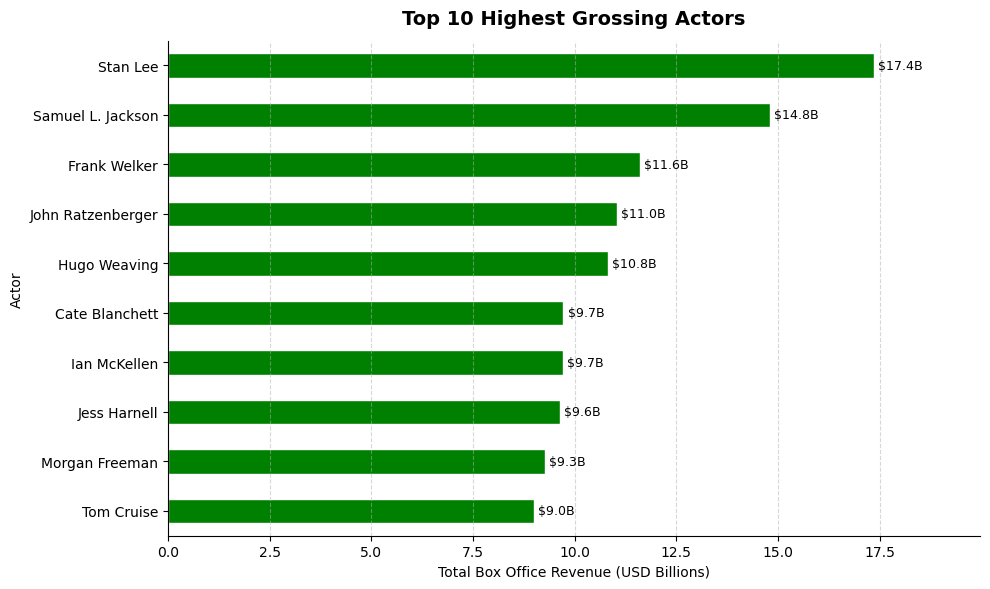

In [22]:
import matplotlib.pyplot as plt

# Build a Series for plotting
top_revenue_billions = pd.Series(
    data  = top_revenues / 1e9,   # convert to billions for readability
    index = top_actors
)

# Plot
ax = top_revenue_billions.plot(
    kind    = "barh",
    figsize = (10, 6),
    color   = "green",
    edgecolor = "white"
)

# Reverse so the highest grossing actor appears at the top
ax.invert_yaxis()

# Add value labels at the end of each bar
for bar, value in zip(ax.patches, top_revenue_billions):
    ax.text(
        value + 0.1,                  # slight offset from bar tip
        bar.get_y() + bar.get_height() / 2,
        f"${value:.1f}B",
        va = "center", fontsize = 9
    )

ax.set_title("Top 10 Highest Grossing Actors", fontsize=14, fontweight="bold", pad=12)
ax.set_xlabel("Total Box Office Revenue (USD Billions)")
ax.set_ylabel("Actor")
ax.set_xlim(0, top_revenue_billions.max() * 1.15)  # headroom for labels
ax.grid(axis="x", linestyle="--", alpha=0.5)
ax.spines[["top", "right"]].set_visible(False)

plt.tight_layout()
plt.show()

# 7. Practical Work 6 plots

## 7.1 Matplotlib plot

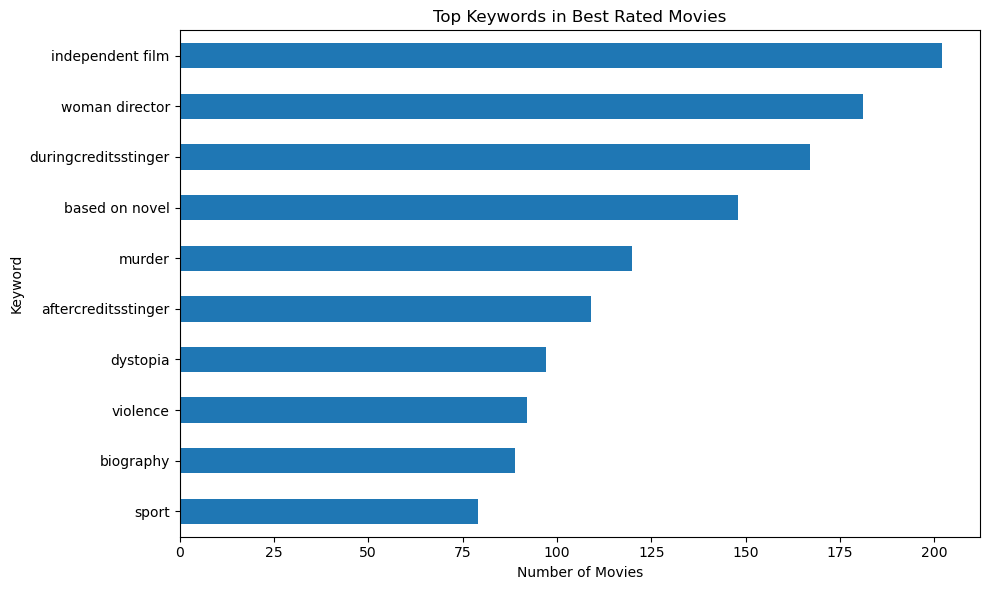

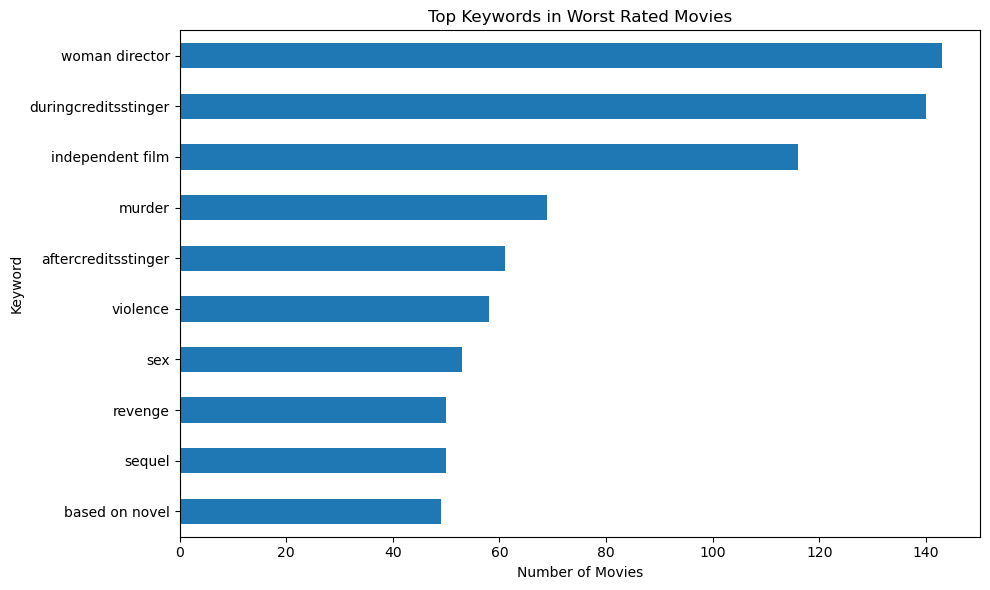

In [29]:
import pandas as pd
import matplotlib.pyplot as plt

# Check average rating
avr_rate = df_main["Average Rating"].mean()

# Movies above average rating and movies below average rating
b_movies = df_main[df_main["Average Rating"] > avr_rate]
w_movies = df_main[df_main["Average Rating"] < avr_rate]


# --------- BEST MOVIES - KEYWORDS --------------- #

b_key_list = []

# Go through keyword cells - best movies
for keywords in b_movies["Keywords"].dropna():

    ws = keywords.split(",")     # Split by comma - as there is multiple ones

    # Going through each keyword now
    for word in ws:

        word = word.strip()      # Remove extra spaces

        # Add only non-empty keywords
        if word != "":
            b_key_list.append(word)

# Convert the list to a Pandas
# Take top 10 most common keywords - sort them for bar chart
top_b_key = (
    pd.Series(b_key_list)
    .value_counts()
    .head(10)
    .sort_values()
)

# Create a horizontal bar chart
top_b_key.plot(
    kind="barh",
    figsize=(10, 6),
    title="Top Keywords in Best Rated Movies"
)

# Display the plot
plt.xlabel("Number of Movies")
plt.ylabel("Keyword")
plt.tight_layout()
plt.show()


# --------- WORST MOVIES - KEYWORDS --------------- #

w_key_list = []

# Go through keyword cells - worst movies
for keywords in w_movies["Keywords"].dropna():

    ws = keywords.split(",")     # Split by comma - as there is multiple ones

    # Going through each keyword now
    for word in ws:

        word = word.strip()      # Remove extra spaces

        # Add only non-empty keywords
        if word != "":
            w_key_list.append(word)

# Convert the list to a Pandas
# Take top 10 most common keywords - sort them for bar chart
top_w_key = (
    pd.Series(w_key_list)
    .value_counts()
    .head(10)
    .sort_values()
)

# Create a horizontal bar chart
top_w_key.plot(
    kind="barh",
    figsize=(10, 6),
    title="Top Keywords in Worst Rated Movies"
)

# Display the plot
plt.xlabel("Number of Movies")
plt.ylabel("Keyword")
plt.tight_layout()
plt.show()

## 7.2 Seaborn plot

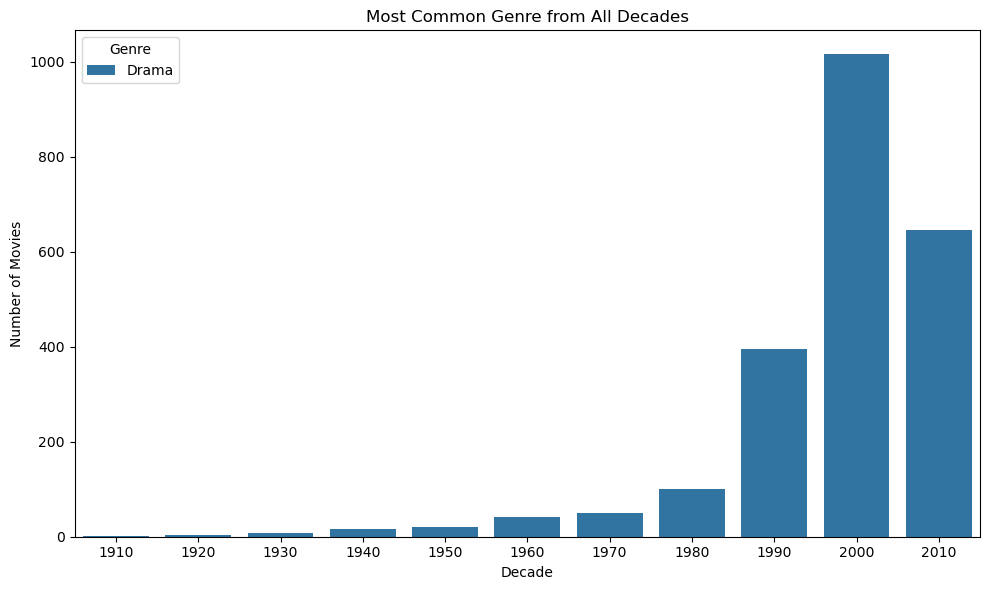

In [28]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

# Lists for fin results
decd_lst = []           # decades
gnr_lst = []            # genres
cnt_lst = []            # count of movies in that genre and decade

# List of all decades
all_decd = []

# Go through all movies
for i in range(len(df_main)):

    rel_date = df_main.loc[i, "Release Date"]       # Getting release date for this movie

    # Check if release date exists!
    if pd.isnull(rel_date) == False:

        yr = int(rel_date[0:4])                     # Take year from release date
        decd = (yr // 10) * 10                      # Get decade

        all_decd.append(decd)                       # Add decade to list

# REMOVE dublication and sort them!
all_decd = sorted(set(all_decd))


# Go through each decade
for decd in all_decd:

    all_gnrs = []                                   # List of all genres

    # Loop through movies - find genres for decade
    for i in range(len(df_main)):

        rel_date = df_main.loc[i, "Release Date"]
        gnrs = df_main.loc[i, "Genres"]

        # Check if release date and genres exist
        if pd.isnull(rel_date) == False and pd.isnull(gnrs) == False:

            yr = int(rel_date[0:4])
            movie_decd = (yr // 10) * 10

            # Is movie from this decade?
            if movie_decd == decd:

                # Split genres in list
                gnrs_split = gnrs.split(",")

                # Add genres one by one
                for gnr in gnrs_split:
                    gnr = gnr.strip()       # Cleanup

                    # Check if not empty
                    if gnr != "":
                        all_gnrs.append(gnr)

    # Count genres
    gnr_cnts = pd.Series(all_gnrs).value_counts()

    # Save most common genre
    decd_lst.append(decd)
    gnr_lst.append(gnr_cnts.index[0])
    cnt_lst.append(gnr_cnts.iloc[0])


# Create DataFrame for visualisation
top_gnr_decd = pd.DataFrame({
    "Decade": decd_lst,
    "Genre": gnr_lst,
    "Movie Count": cnt_lst
})

# Create graph
plt.figure(figsize=(10, 6))

sns.barplot(
    data=top_gnr_decd,
    x="Decade",
    y="Movie Count",
    hue="Genre"
)

plt.title("Most Common Genre from All Decades")
plt.xlabel("Decade")
plt.ylabel("Number of Movies")
plt.tight_layout()
plt.show()

## 7.3 Additional plots

In addition, it is possible to create a correlation matrix using the numerical values from our dataframe.

In [25]:
df_corr = df_main[ ["Budget", "Popularity", "Revenue", "Runtime", "Average Rating", "Rating votes"] ]
df_corr.head()

,Budget,Popularity,Revenue,Runtime,Average Rating,Rating votes
0,237000000,150.437577,2787965087,162.0,7.2,11800
1,300000000,139.082615,961000000,169.0,6.9,4500
2,245000000,107.376788,880674609,148.0,6.3,4466
3,250000000,112.312950,1084939099,165.0,7.6,9106
4,260000000,43.926995,284139100,132.0,6.1,2124


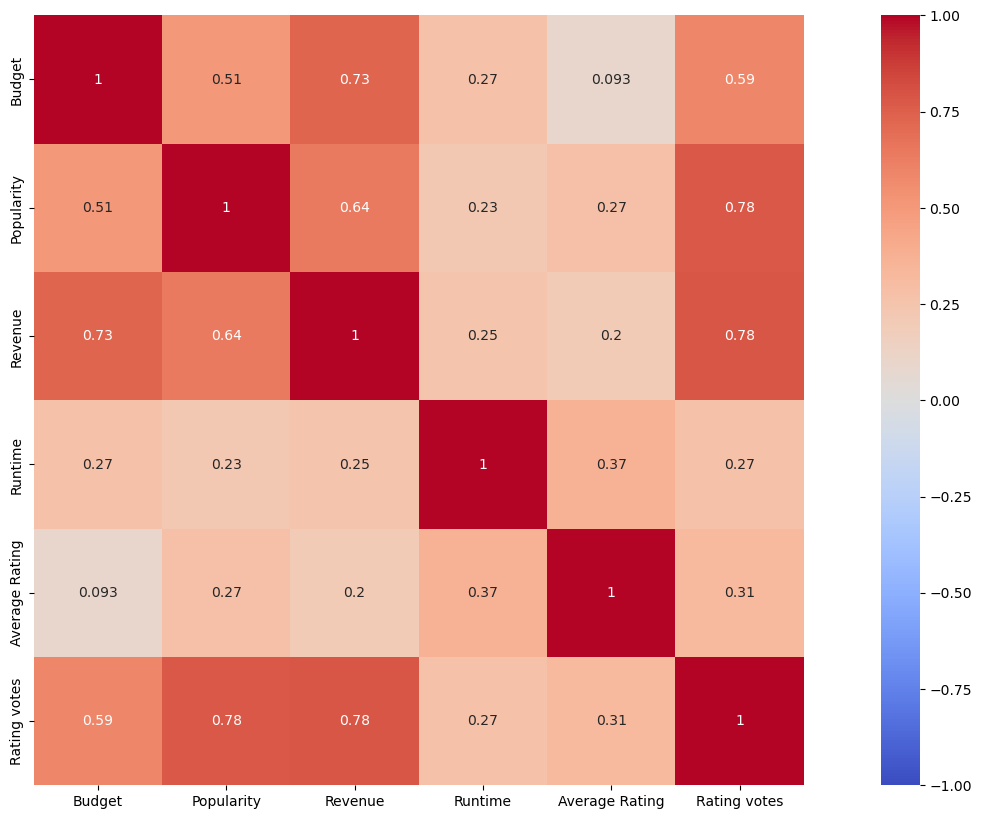

In [26]:
corr_matrix=df_corr.corr(method='pearson')    # create a correlation matrix using the Pearson method

plt.figure(figsize=(20,10))
sns.heatmap(
    corr_matrix,                             # depicted object
    vmax=1, vmin=-1,                         # min and max values for color map
    square=True,annot=True, cmap="coolwarm"  # formatting: square; specified values; color map
)
plt.show()

We can then create a linear model on the two most positively correlated values.

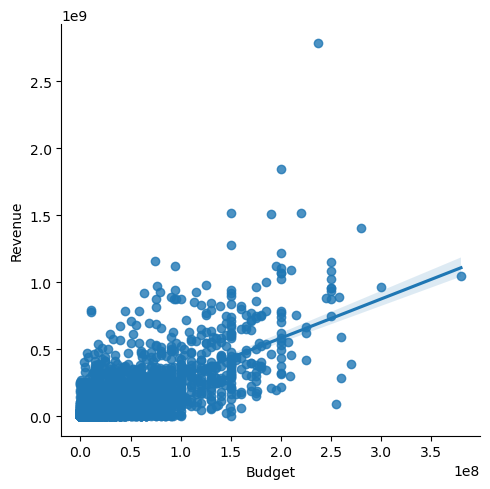

In [27]:
sns.lmplot(data = df_corr, x = "Budget", y = "Revenue")
plt.show()

# 8. Sources used

pandas. (2026, June 5). *pandas.DataFrame.reset_index*. Pandas 3.0.3 documentation.  https://pandas.pydata.org/docs/reference/api/pandas.DataFrame.reset_index.html